In [230]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor

In [231]:
df = pd.read_csv('concrete_data.csv')

In [232]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [233]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [234]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [235]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [236]:
df.columns

Index(['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer',
       'Coarse Aggregate', 'Fine Aggregate', 'Age', 'Strength'],
      dtype='object')

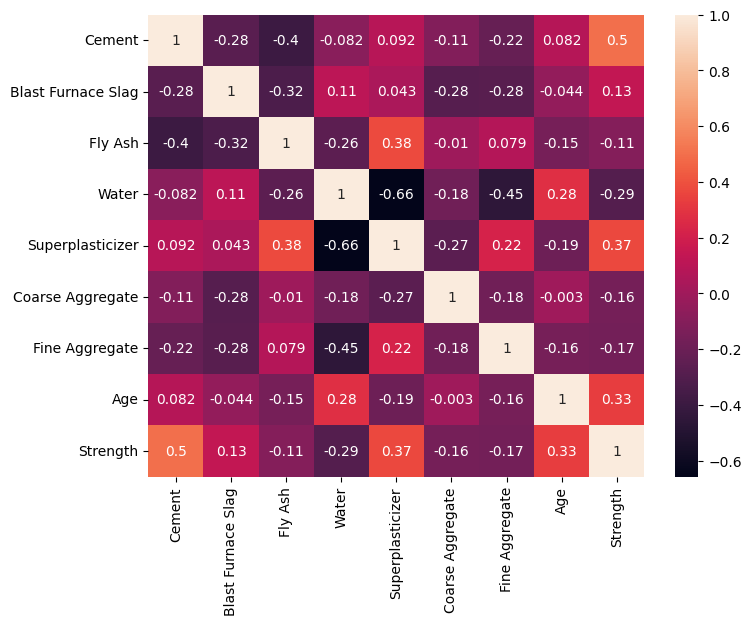

In [237]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True)
plt.show()

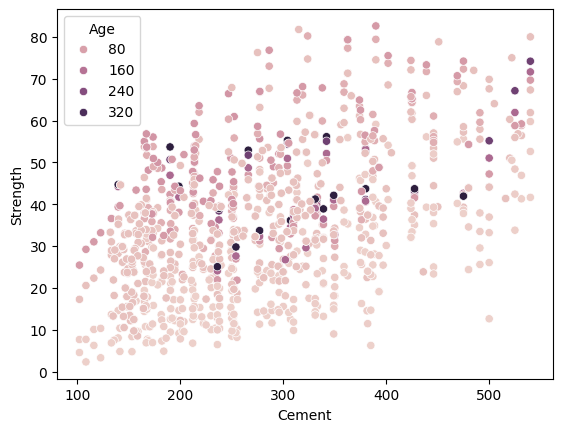

In [238]:
sns.scatterplot(data=df, x ="Cement", y="Strength", hue="Age")
plt.show()

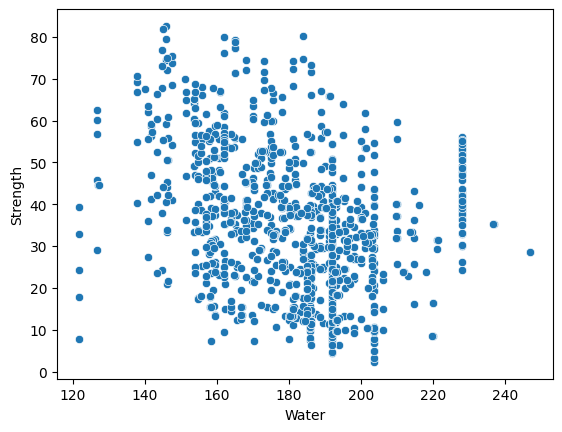

In [239]:
sns.scatterplot(data=df, x ="Water", y="Strength")
plt.show()

In [240]:
# dependent feature -> Strength
X = df.drop("Strength", axis=1)
y = df["Strength"]

In [241]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.5, random_state=15)

In [242]:
# Gradient Boosting'i daha iyi anlamak için manuel olarak yapıyoruz burada !!!

In [243]:
from sklearn.tree import DecisionTreeRegressor

In [244]:
# first weak learner
tree_reg1 = DecisionTreeRegressor(max_depth=3)
tree_reg1.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [245]:
# Residual Error from the first decision tree
y2 = y_train - tree_reg1.predict(X_train)

In [246]:
y2[:5]

111    15.147742
412    -1.099079
877     0.850352
765    -2.206667
774   -13.956667
Name: Strength, dtype: float64

In [247]:
# second weak learner
# bunu y_train ile değil, y2 ile (ilk dt'den kalan hatalar) uyguluyoruz

tree_reg2 = DecisionTreeRegressor(max_depth=4)
tree_reg2.fit(X_train, y2)

,criterion,'squared_error'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [248]:
y3 = y2 - tree_reg2.predict(X_train)
y3[:5]

111     7.124324
412     1.809020
877     4.788887
765     1.731868
774   -10.018132
Name: Strength, dtype: float64

In [249]:
# third weak learner
tree_reg3 = DecisionTreeRegressor(max_depth=4)
tree_reg3.fit(X_train, y3)

,criterion,'squared_error'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [250]:
y4 = y3 - tree_reg3.predict(X_train)
y4[:5] 

111    5.140318
412    2.192735
877    2.406976
765    3.364455
774   -8.385545
Name: Strength, dtype: float64

In [251]:
y_pred = sum(tree.predict(X_test) for tree in (tree_reg1, tree_reg2, tree_reg3))

In [252]:
from sklearn.metrics import r2_score

In [253]:
r2_score(y_test,y_pred)

0.7710671973292751

In [254]:
tree_reg4 = DecisionTreeRegressor(max_depth=4)
tree_reg4.fit(X_train, y4)

,criterion,'squared_error'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [255]:
y_pred = sum(tree.predict(X_test) for tree in (tree_reg1, tree_reg2, tree_reg3, tree_reg4))

In [256]:
r2_score(y_test,y_pred)

0.7875923569587955

In [257]:
###################################################################################################################################################

In [258]:
gbr = GradientBoostingRegressor(n_estimators=3, max_depth=3, learning_rate=0.1) # Hyperparameter tuning burada çok önemli olacak !!!

In [259]:
gbr.fit(X_train,y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,3
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [260]:
y_pred = gbr.predict(X_test)
r2_score(y_test, y_pred)

0.2906341366587294

In [261]:
gbr = GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.1)
gbr.fit(X_train,y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [262]:
y_pred = gbr.predict(X_test)
r2_score(y_test, y_pred) # n_estimators 3 aşırı düşük bir değer !!

0.8935501344788384

In [263]:
# hyperparameter tuning

In [264]:
params = {
    "n_estimators": [100,150,200],
    "max_depth" : [3,4,5],
    "loss" : ["squared_error", "absolute_error", "huber", "quantile"],
    "learning_rate": [0.01, 0.1, 0.5]
}

In [265]:
rscv = RandomizedSearchCV(estimator=GradientBoostingRegressor(), param_distributions=params, cv=5)

In [266]:
rscv.fit(X_train, y_train)

,estimator,GradientBoostingRegressor()
,param_distributions,"{'learning_rate': [0.01, 0.1, ...], 'loss': ['squared_error', 'absolute_error', ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 150, ...]}"
,n_iter,10
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [267]:
rscv.best_params_

{'n_estimators': 150, 'max_depth': 3, 'loss': 'huber', 'learning_rate': 0.1}

In [268]:
y_pred = rscv.predict(X_test)
r2_score(y_test,y_pred)

0.9106762990499482